# **Datenbereinigung**

Da die Daten der WHO in mehreren CSV-Dateien gespeichert wurden, habe ich mir zur besseren Übersicht der in meinen ausgewählten Datensätzen vorkommenden Spalten mithilfe des WHO Data Dictionary eine Übersicht über die Spalten und ihre Bezeichnungen erstellt (`TB_extended_column_names.csv`). In diesem Notebook werden der Auswahlprozess und die Datenbereinigung dokumentiert, ohne alle Spalten der sehr großen Rohdatensätze erneut vollständig auszugeben.

## Inhaltsangabe

1. Datenimport
2. Plan
3. Übersicht der CSV-Daten und Erstellung reduzierter Datensätze
4. Zusammenführung mit Validierung
5. Feature Engineering und Plausibilitätsprüfung
6. Finale Validierung und Export


## Amendments nach der ersten Abgabe und Datenvisualisierung


Im Verlauf der explorativen Analyse zeigte sich zum Einen, dass neben den ursprünglich geplanten Zusammenhangsanalysen auch zeitliche Entwicklungen auf Länder-Jahr-Ebene betrachtet werden müssen. Dadurch ergab sich zusätzlicher Bedarf bei einer Analyse nur Länder zu berücksichtigen, die in allen betrachteten Jahren valide Werte hatten. Außerdem wurde eine kategoriale Beschreibung der Richtung der Fallzahlveränderung nötig (Anstieg / Rückgang). 

Zum Anderen erfolgte die Einarbeitung des Feedbacks und weitere Anpassungen, die im Rahmen der Datanvisualisierung aufgefallen waren: Hinzufügen von Begründungen, Plausibilitäts-Korrekturen, sowie nachträgliche Ergänzung von Merkmalen/Flags. 

| ID | Änderung | Begründung |
|---|---|---|
| A1 | Resistenzraten neuer TB-Fälle von exakt `1.0` auf `NaN` gesetzt | Eine 100%ige Resistenzlage ist fachlich unplausibel, daher werden die Randwerte auf `NaN` gesetzt. |
| A2 | `newrel_coh_next_year` ergänzt | Die Folgejahres-Kohortengröße wird als Kontextvariable mitgeführt, damit Outcome-Raten von 1.0 im Folgejahr zusammen mit der zugrunde liegenden Fallzahl interpretiert werden können.|
| A3 | `newinc_con_tb` beibehalten, `used_2021_defs_flg` entfernt | `newinc_con_tb` bleibt als explorative Zusatzvariable erhalten; das versehentlich mitgeführte Flag wird nicht in den Analyseexport übernommen. |
| A4 | Extreme Fallzahlveränderungen eingeordnet | Rechnerisch plausible Extremwerte können reale epidemiologische oder meldungsbedingte Veränderungen darstellen und sind nicht automatisch Datenfehler. |
| A5 | `case_change_direction` ergänzt | Für die deskriptive Länder-Jahr-Analyse wird zwischen Rückgang, unveränderten Fallzahlen und Anstieg unterschieden. |
| A6 | `temporal_analysis_cohort_flag` ergänzt | Kennzeichnung einer konstanten Länder-Analysegruppe: Diese Flag haben Länder enthalten, die für alle Ausgangsjahre 2019-2023 mindestens 10 Ausgangsfällen in jedem Jahr besaßen. |
| A7 | Regionale Datenabdeckung ergänzt und eingeordnet| Länderzahlen werden relativ zum WHO-Ausgangsdatensatz eingeordnet, statt nur absolute Länder-Jahr-Zahlen zu vergleichen. |

Die jeweilige Umsetzung bleibt an der fachlich passenden Stelle der Pipeline mit der Amendment-ID gekennzeichnet.


## 1. Datenimport

In [11]:
import pandas as pd

contact = pd.read_csv("data/TB_contact_tpt_2026-04-29.csv")
notifications = pd.read_csv("data/TB_notifications_2026-04-29.csv")
drug_resistance = pd.read_csv("data/TB_dr_surveillance_2026-04-29.csv")
outcomes = pd.read_csv("data/TB_outcomes_2026-04-29.csv")


## 2. Plan

#### Data-Cleanup-Plan

- Rohdatensätze kurz inspizieren, um Umfang und Struktur einzuordnen
- Relevante Spalten anhand der Forschungsfrage, der Datenverfügbarkeit und des Data Dictionary auswählen
- Pro CSV einen reduzierten DataFrame erstellen
- Danach die Datensätze über `iso3` und `year` zusammenführen
- NA-Werte, Duplikate und Plausibilität im zusammengeführten Datensatz prüfen

## 3. Übersicht der CSV-Daten und Erstellung reduzierter Datensätze

### 1. Contact-CSV

Die Contact-CSV enthält Informationen zu Kontaktpersonen von TB-Fällen, Screening und präventiver TB-Behandlung. Für die Forschungsfrage sind vor allem Variablen relevant, mit denen sich Screening-Aktivität und präventive Behandlung abbilden lassen.

In [12]:
contact.shape

(2150, 36)

Aus fachlicher Sicht machen in der Contact-CSV folgende Spalten Sinn:

| Spalte | Bedeutung | Fehlende Werte |
|---|---|---:|
| `country` | Land bzw. Gebiet | 0.00 % |
| `iso3` | ISO-3-Ländercode; wichtig zum Zusammenführen der Datensätze | 0.00 % |
| `year` | Berichtsjahr | 0.00 % |
| `g_whoregion` | WHO-Region | 0.00 % |
| `screen_data_available` | Gibt an, ob Daten zur Untersuchung von Kontaktpersonen verfügbar sind | 47.26 % |
| `newinc_con` | Anzahl der Haushaltskontaktpersonen von bakteriologisch bestätigten pulmonalen neuen und Rückfall-TB-Fällen | 64.23 % |
| `newinc_con_screen` | Anzahl der Kontaktpersonen, die auf aktive TB und latente TB untersucht wurden | 63.67 % |
| `newinc_con_tb` | Anzahl der Haushaltskontaktpersonen von bakteriologisch bestätigten pulmonalen neuen und Rückfall-TB-Fällen, bei denen TB diagnostiziert wurde | 82.47 % |
| `prevtx_data_available` | Gibt an, ob Daten zum Beginn einer präventiven TB-Behandlung bei Kontaktpersonen verfügbar sind | 10.93 % |
| `newinc_con_prevtx` | Anzahl der Kontaktpersonen, die eine präventive TB-Behandlung begonnen haben | 55.49 % |
| `newinc_con04_prevtx` | Anzahl der Kinder unter 5 Jahren, die als Kontaktpersonen eine präventive TB-Behandlung begonnen haben | 39.63 % |
| `newinc_con_prevtx_cmplt` | Anzahl der Kontaktpersonen, die eine präventive TB-Behandlung abgeschlossen haben | 79.16 % |

Ferner sind aus diesen Werten weitere Spalten generierbar, die bei der Betrachtung der Frage sinnhaft sind:
- `contact_screening_rate = newinc_con_screen / newinc_con` als Maß für die Screening-Abdeckung der Kontaktpersonen
- `tpt_start_rate = newinc_con_prevtx / newinc_con` als relative Aussage über den Beginn einer präventiven Therapie

Aus fachlicher Sicht wäre auch die `tpt_completion_rate = newinc_con_prevtx_cmplt / newinc_con_prevtx` als Maß für die Therapieadhärenz sehr spannend, jedoch fehlen dafür viele Daten in der Spalte der abgeschlossenen Behandlung.

**Amendment A3:** Variablen, mit hohen fehlend-Werten wie `newinc_con_tb`und `newinc_con_prevtx_cmplt` wurden behalten, da angedacht war, sie in der Datenvisualisierung als zusätzliche Kontextinformation zu verwenden.


In [13]:
contact_cols = [
    "country",
    "iso3",
    "year",
    "g_whoregion",
    "screen_data_available",
    "newinc_con",
    "newinc_con_screen",
    "newinc_con_tb",
    "prevtx_data_available",
    "newinc_con_prevtx",
    "newinc_con04_prevtx",
    "newinc_con_prevtx_cmplt",
]

contact_selected = contact[contact_cols].copy()


Nach der fachlichen Auswahl wird nur noch der reduzierte Contact-Datensatz inspiziert.

In [14]:
contact_selected.shape

(2150, 12)

In [15]:
contact_selected.head()

,country,iso3,year,g_whoregion,screen_data_available,newinc_con,newinc_con_screen,newinc_con_tb,prevtx_data_available,newinc_con_prevtx,newinc_con04_prevtx,newinc_con_prevtx_cmplt
0,Afghanistan,AFG,2015,EMR,NaN,NaN,NaN,NaN,60.0,NaN,10164.0,NaN
1,Afghanistan,AFG,2016,EMR,NaN,NaN,NaN,NaN,60.0,NaN,15417.0,NaN
2,Afghanistan,AFG,2017,EMR,NaN,NaN,NaN,NaN,60.0,NaN,24666.0,NaN
3,Afghanistan,AFG,2018,EMR,NaN,NaN,NaN,NaN,60.0,22467.0,22467.0,NaN
4,Afghanistan,AFG,2019,EMR,60.0,32737.0,29469.0,NaN,60.0,24701.0,24701.0,21505.0


In [16]:
contact_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2150 entries, 0 to 2149
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country                  2150 non-null   object 
 1   iso3                     2150 non-null   object 
 2   year                     2150 non-null   int64  
 3   g_whoregion              2150 non-null   object 
 4   screen_data_available    1134 non-null   float64
 5   newinc_con               769 non-null    float64
 6   newinc_con_screen        781 non-null    float64
 7   newinc_con_tb            377 non-null    float64
 8   prevtx_data_available    1915 non-null   float64
 9   newinc_con_prevtx        957 non-null    float64
 10  newinc_con04_prevtx      1298 non-null   float64
 11  newinc_con_prevtx_cmplt  448 non-null    float64
dtypes: float64(8), int64(1), object(3)
memory usage: 201.7+ KB


In [17]:
contact_selected.isna().mean().mul(100).sort_values(ascending=False)

newinc_con_tb              82.465116
newinc_con_prevtx_cmplt    79.162791
newinc_con                 64.232558
newinc_con_screen          63.674419
newinc_con_prevtx          55.488372
screen_data_available      47.255814
newinc_con04_prevtx        39.627907
prevtx_data_available      10.930233
country                     0.000000
iso3                        0.000000
year                        0.000000
g_whoregion                 0.000000
dtype: float64

### 2. Notifications-CSV

Die Notifications-CSV enthält gemeldete TB-Fälle nach Land und Jahr. Für die spätere Analyse ist sie besonders wichtig, weil aus `c_newinc` sowohl die Fallzahl im Folgejahr als auch die prozentuale Veränderung der gemeldeten TB-Fälle vom aktuellen Jahr zum Folgejahr gebildet werden kann.


In [18]:
notifications.shape

(9567, 216)

Für die Notifications-CSV werden folgende Spalten ausgewählt:

| Spalte | Bedeutung | Fehlende Werte |
|---|---|---:|
| `country` | Land bzw. Gebiet | 0.00 % |
| `iso3` | ISO-3-Ländercode; wichtig zum Zusammenführen der Datensätze | 0.00 % |
| `year` | Berichtsjahr | 0.00 % |
| `g_whoregion` | WHO-Region | 0.00 % |
| `c_newinc` | Gesamtzahl der gemeldeten neuen und Rückfall-TB-Fälle sowie Fälle mit unbekannter vorheriger Behandlungshistorie | 6.01 % |
| `new_labconf` | Neue pulmonale bakteriologisch bestätigte TB-Fälle | 50.97 % |
| `new_clindx` | Neue pulmonale klinisch diagnostizierte TB-Fälle | 74.05 % |
| `new_ep` | Neue extrapulmonale TB-Fälle | 36.74 % |

`c_newinc` ist die zentrale Fallzahlvariable. Da absolute Fallzahlen ohne Bevölkerungsdaten nur eingeschränkt zwischen Ländern vergleichbar sind, wird daraus später die prozentuale Veränderung der gemeldeten TB-Fälle vom aktuellen Jahr zum Folgejahr abgeleitet.

Ferner sind aus diesen Werten weitere Spalten generierbar, die bei der Betrachtung der Frage sinnhaft sind:
- `new_pulmonary = new_labconf + new_clindx` als Anzahl neuer pulmonaler TB-Fälle
- `c_newinc_percent_change_next_year = ((c_newinc_next_year - c_newinc) / c_newinc) * 100` als prozentuale Veränderung der gemeldeten TB-Fälle im Folgejahr


In [19]:
notifications_cols = [
    "country",
    "iso3",
    "year",
    "g_whoregion",
    "c_newinc",
    "new_labconf",
    "new_clindx",
    "new_ep",
]

notifications_selected = notifications[notifications_cols].copy()

Nach der fachlichen Auswahl wird nur noch der reduzierte Notifications-Datensatz inspiziert.

In [20]:
notifications_selected.shape

(9567, 8)

In [21]:
notifications_selected.head()

,country,iso3,year,g_whoregion,c_newinc,new_labconf,new_clindx,new_ep
0,Afghanistan,AFG,1980,EMR,71685.0,NaN,NaN,NaN
1,Afghanistan,AFG,1981,EMR,71554.0,NaN,NaN,NaN
2,Afghanistan,AFG,1982,EMR,41752.0,NaN,NaN,NaN
3,Afghanistan,AFG,1983,EMR,52502.0,NaN,NaN,NaN
4,Afghanistan,AFG,1984,EMR,18784.0,NaN,NaN,NaN


In [22]:
notifications_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9567 entries, 0 to 9566
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      9567 non-null   object 
 1   iso3         9567 non-null   object 
 2   year         9567 non-null   int64  
 3   g_whoregion  9567 non-null   object 
 4   c_newinc     8992 non-null   float64
 5   new_labconf  4691 non-null   float64
 6   new_clindx   2483 non-null   float64
 7   new_ep       6052 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 598.1+ KB


In [23]:
notifications_selected.isna().mean().mul(100).sort_values(ascending=False)

new_clindx     74.046200
new_labconf    50.966865
new_ep         36.740880
c_newinc        6.010244
country         0.000000
iso3            0.000000
year            0.000000
g_whoregion     0.000000
dtype: float64


### 3. Drug-Resistance-CSV 

Das CSV enthält Daten zu Medikamentenresistenzen bei Tuberkulose. Dabei wird eine Einteilung vorgenommen in "resistent" Tuberkulose, die eine Resistenz gegen das Antibiotikum Rifampicin (RMP) aufweist sowie in MDR (Multi-Drug-Resistant)-TB, die eine Resistenz gegen RMP und das Antibiotikum Isoniazid (INH) aufweist. Der Vollständigkeit halber sei erwähnt, dass es noch eine ausgeprägtere Resistenzform gibt, die in den vorliegenden Daten aber nur wenig vertreten ist und daher nicht in die Analyse mit einfließt.

In [24]:
drug_resistance.shape

(1720, 57)

Für die Drug-Resistance-CSV werden folgende Spalten ausgewählt:

| Spalte | Bedeutung | Fehlende Werte |
|---|---|---:|
| `country` | Land bzw. Gebiet | 0.00 % |
| `iso3` | ISO-3-Ländercode; wichtig zum Zusammenführen der Datensätze | 0.00 % |
| `year` | Berichtsjahr | 0.00 % |
| `g_whoregion` | WHO-Region | 0.00 % |
| `r_rlt_new` | Anzahl neuer bakteriologisch bestätigter pulmonaler TB-Fälle mit Testergebnis für Rifampicin | 10.70 % |
| `rr_new` | Anzahl neuer bakteriologisch bestätigter pulmonaler TB-Fälle mit Rifampicin-Resistenz | 10.52 % |
| `dst_rlt_new` | Anzahl neuer pulmonaler TB-Fälle mit Testergebnis für Isoniazid und Rifampicin | 16.86 % |
| `mdr_new` | Anzahl neuer TB-Fälle mit MDR-TB unter den Fällen mit Resistenztestung | 17.03 % |
| `r_rlt_ret` | Anzahl vorbehandelter bakteriologisch bestätigter pulmonaler TB-Fälle mit Testergebnis für Rifampicin | 12.79 % |
| `rr_ret` | Anzahl vorbehandelter bakteriologisch bestätigter pulmonaler TB-Fälle mit Rifampicin-Resistenz | 13.14 % |
| `dst_rlt_ret` | Anzahl vorbehandelter TB-Fälle mit Testergebnis für Isoniazid und Rifampicin | 18.26 % |
| `mdr_ret` | Anzahl vorbehandelter TB-Fälle mit MDR-TB unter den Fällen mit Resistenztestung | 18.49 % |

Für die Forschungsfrage sind nicht nur absolute Zahlen der resistenten Fälle relevant, sondern vor allem Anteile. Absolute Zahlen hängen stark von der Größe des Landes und der Anzahl durchgeführter Tests ab.

Daher sind aus diesen Werten weitere Spalten generierbar, die bei der Betrachtung der Frage sinnhaft sind:
- `rr_rate_new = rr_new / r_rlt_new` als Anteil neuer Fälle mit Rifampicin-Resistenz
- `mdr_rate_new = mdr_new / dst_rlt_new` als Anteil neuer Fälle mit MDR-TB
- `rr_rate_ret = rr_ret / r_rlt_ret` als Anteil vorbehandelter Fälle mit Rifampicin-Resistenz
- `mdr_rate_ret = mdr_ret / dst_rlt_ret` als Anteil vorbehandelter Fälle mit MDR-TB

Die Variablen zu vorbehandelten Fällen werden zunächst mit aufgenommen, aber eher explorativ betrachtet. Für die Hauptanalyse sind `rr_rate_new` und `mdr_rate_new` wichtiger, weil sie sich auf neue TB-Fälle beziehen.

In [25]:
drug_resistance_cols = [
    "country",
    "iso3",
    "year",
    "g_whoregion",
    "r_rlt_new",
    "rr_new",
    "dst_rlt_new",
    "mdr_new",
    "r_rlt_ret",
    "rr_ret",
    "dst_rlt_ret",
    "mdr_ret",
]

drug_resistance_selected = drug_resistance[drug_resistance_cols].copy()

Nach der fachlichen Auswahl wird nur noch der reduzierte Drug-Resistance-Datensatz inspiziert.

In [26]:
drug_resistance_selected.shape

(1720, 12)

In [27]:
drug_resistance_selected.head()

,country,iso3,year,g_whoregion,r_rlt_new,rr_new,dst_rlt_new,mdr_new,r_rlt_ret,rr_ret,dst_rlt_ret,mdr_ret
0,Afghanistan,AFG,2017,EMR,2889.0,NaN,NaN,NaN,2233.0,NaN,NaN,NaN
1,Afghanistan,AFG,2018,EMR,10032.0,253.0,NaN,NaN,1628.0,199.0,10.0,10.0
2,Afghanistan,AFG,2019,EMR,5443.0,263.0,23.0,23.0,918.0,221.0,20.0,20.0
3,Afghanistan,AFG,2020,EMR,10255.0,280.0,563.0,105.0,642.0,144.0,NaN,NaN
4,Afghanistan,AFG,2021,EMR,17443.0,390.0,NaN,NaN,501.0,69.0,NaN,NaN


In [28]:
drug_resistance_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1720 entries, 0 to 1719
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      1720 non-null   object 
 1   iso3         1720 non-null   object 
 2   year         1720 non-null   int64  
 3   g_whoregion  1720 non-null   object 
 4   r_rlt_new    1536 non-null   float64
 5   rr_new       1539 non-null   float64
 6   dst_rlt_new  1430 non-null   float64
 7   mdr_new      1427 non-null   float64
 8   r_rlt_ret    1500 non-null   float64
 9   rr_ret       1494 non-null   float64
 10  dst_rlt_ret  1406 non-null   float64
 11  mdr_ret      1402 non-null   float64
dtypes: float64(8), int64(1), object(3)
memory usage: 161.4+ KB


In [29]:
drug_resistance_selected.isna().mean().mul(100).sort_values(ascending=False)

mdr_ret        18.488372
dst_rlt_ret    18.255814
mdr_new        17.034884
dst_rlt_new    16.860465
rr_ret         13.139535
r_rlt_ret      12.790698
r_rlt_new      10.697674
rr_new         10.523256
country         0.000000
iso3            0.000000
year            0.000000
g_whoregion     0.000000
dtype: float64

### 4. Outcome-CSV

In diesem Datensatz finden sich Daten zu den Therapieerfolgen (Therapie beendet / geheilt) bzw. Misserfolgen (nicht beendet, verstorben, lost-to-follow-up). 

In [30]:
outcomes.shape

(6399, 73)

Für die Outcome-CSV werden folgende Spalten ausgewählt:

| Spalte | Bedeutung | Fehlende Werte |
|---|---|---:|
| `country` | Land bzw. Gebiet | 0.00 % |
| `iso3` | ISO-3-Ländercode; wichtig zum Zusammenführen der Datensätze | 0.00 % |
| `year` | Berichtsjahr | 0.00 % |
| `g_whoregion` | WHO-Region | 0.00 % |
| `newrel_coh` | Kohortengröße für neue und Rückfall-TB-Fälle; falls `rel_with_new_flg = 0`, nur neue Fälle | 63.42 % |
| `newrel_succ` | Anzahl erfolgreich behandelter Fälle, also geheilt oder Behandlung abgeschlossen | 63.60 % |
| `newrel_fail` | Anzahl der Fälle mit Therapieversagen | 64.14 % |
| `newrel_died` | Anzahl der verstorbenen Fälle | 63.82 % |
| `newrel_lost` | Anzahl der Fälle mit lost to follow-up | 63.98 % |
| `c_new_tsr` | Therapieerfolgsrate für neue Fälle in Prozent; Rückfälle sind enthalten, wenn `rel_with_new_flg = 1` | 17.22 % |
| `rel_with_new_flg` | Flag, ob Rückfall-Fälle in den `newrel`-Outcome-Variablen enthalten sind | 63.35 % |

`c_new_tsr` ist bereits als Therapieerfolgsrate vorhanden und hat weniger fehlende Werte als die absoluten Outcome-Zahlen. Die absoluten Spalten werden trotzdem aufgenommen, weil daraus eigene Raten für Erfolg, Tod, Therapieversagen und lost to follow-up berechnet werden können.

Ferner sind aus diesen Werten weitere Spalten generierbar, die bei der Betrachtung der Frage sinnhaft sind:
- `treatment_success_rate = newrel_succ / newrel_coh` als selbst berechnete Therapieerfolgsrate
- `treatment_failure_rate = newrel_fail / newrel_coh` als Anteil mit Therapieversagen
- `treatment_death_rate = newrel_died / newrel_coh` als Anteil der verstorbenen Fälle
- `lost_to_followup_rate = newrel_lost / newrel_coh` als Anteil der Fälle mit lost to follow-up
- `unsuccessful_rate = (newrel_fail + newrel_died + newrel_lost) / newrel_coh` als zusammengefasster Anteil nicht erfolgreicher Outcomes

**Amendment A3:** Das Flag `used_2021_defs_flg` wird hier nicht weitergeführt, da es versehentlich mitgeführt wurde und nicht Teil der Kernanalyse ist.


In [31]:
outcomes_cols = [
    "country",
    "iso3",
    "year",
    "g_whoregion",
    "newrel_coh",
    "newrel_succ",
    "newrel_fail",
    "newrel_died",
    "newrel_lost",
    "c_new_tsr",
    "rel_with_new_flg",
]

outcomes_selected = outcomes[outcomes_cols].copy()


Nach der fachlichen Auswahl wird nur noch der reduzierte Outcome-Datensatz inspiziert.

In [32]:
outcomes_selected.shape

(6399, 11)

In [33]:
outcomes_selected.head()

,country,iso3,year,g_whoregion,newrel_coh,newrel_succ,newrel_fail,newrel_died,newrel_lost,c_new_tsr,rel_with_new_flg
0,Afghanistan,AFG,1994,EMR,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,1995,EMR,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,1996,EMR,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,1997,EMR,NaN,NaN,NaN,NaN,NaN,45.0,NaN
4,Afghanistan,AFG,1998,EMR,NaN,NaN,NaN,NaN,NaN,33.0,NaN


In [34]:
outcomes_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6399 entries, 0 to 6398
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country           6399 non-null   object 
 1   iso3              6399 non-null   object 
 2   year              6399 non-null   int64  
 3   g_whoregion       6399 non-null   object 
 4   newrel_coh        2341 non-null   float64
 5   newrel_succ       2329 non-null   float64
 6   newrel_fail       2295 non-null   float64
 7   newrel_died       2315 non-null   float64
 8   newrel_lost       2305 non-null   float64
 9   c_new_tsr         5297 non-null   float64
 10  rel_with_new_flg  2345 non-null   float64
dtypes: float64(7), int64(1), object(3)
memory usage: 550.0+ KB


In [35]:
outcomes_selected.isna().mean().mul(100).sort_values(ascending=False)

newrel_fail         64.135021
newrel_lost         63.978747
newrel_died         63.822472
newrel_succ         63.603688
newrel_coh          63.416159
rel_with_new_flg    63.353649
c_new_tsr           17.221441
country              0.000000
iso3                 0.000000
year                 0.000000
g_whoregion          0.000000
dtype: float64

## 4. Zusammenführung mit Validierung

### Zusammenführen der reduzierten Datensätze in einen gemeinsamen Datensatz 
--> Über die gemeinsamen Spalten: `iso3` und `year`

Dafür erfolgt zunächst die Prüfung, ob die oben genannten Spalten wirklich eindeutig sind.

In [36]:
key_cols = ["iso3", "year"]

print("contact:", contact_selected.duplicated(subset=key_cols).sum())
print("notifications:", notifications_selected.duplicated(subset=key_cols).sum())
print("drug_resistance:", drug_resistance_selected.duplicated(subset=key_cols).sum())
print("outcomes:", outcomes_selected.duplicated(subset=key_cols).sum())

contact: 0
notifications: 0
drug_resistance: 0
outcomes: 0


Die Spalten eignen sich gut, um die Datensätze darüber zusammenzuführen. Dabei wird ein Left-Join verwendet, damit keine Contact-Zeilen verloren gehen. Wenn in einer anzufügenden Tabelle kein passender Eintrag vorhanden ist, entstehen dort fehlende Werte.

In [37]:
tb_merged = (
    contact_selected
    .merge(
        notifications_selected,
        on=["iso3", "year"],
        how="left",
        suffixes=("", "_notifications")
    )
    .merge(
        drug_resistance_selected,
        on=["iso3", "year"],
        how="left",
        suffixes=("", "_drug_resistance")
    )
    .merge(
        outcomes_selected,
        on=["iso3", "year"],
        how="left",
        suffixes=("", "_outcomes")
    )
)
# Verifikation, dass keine Zeilen vermehrt wurden
contact_selected.shape[0], tb_merged.shape[0]

(2150, 2150)

### Missing-Value-Check nach dem Merge

In [38]:
tb_merged.isna().mean().mul(100).sort_values(ascending=False)

newinc_con_tb                  82.465116
newinc_con_prevtx_cmplt        79.162791
newinc_con                     64.232558
newinc_con_screen              63.674419
newinc_con_prevtx              55.488372
screen_data_available          47.255814
newinc_con04_prevtx            39.627907
mdr_ret                        34.790698
dst_rlt_ret                    34.604651
mdr_new                        33.627907
dst_rlt_new                    33.488372
rr_ret                         30.511628
r_rlt_ret                      30.232558
r_rlt_new                      28.558140
rr_new                         28.418605
c_new_tsr                      20.790698
newrel_fail                    20.232558
g_whoregion_drug_resistance    20.000000
country_drug_resistance        20.000000
newrel_lost                    19.720930
newrel_died                    19.488372
newrel_succ                    19.069767
newrel_coh                     18.604651
rel_with_new_flg               18.418605
prevtx_data_avai

Nach dem Zusammenführen der vier reduzierten Datensätze wurden die fehlenden Daten im gemeinsamen Datensatz geprüft.

Die Notifications-Daten konnten vollständig an die Contact-Daten gemappt werden (`country_notifications` und `g_whoregion_notifications` ohne fehlende Werte). Für die Drug-Resistance-Daten fehlen passende Einträge für 20 % der Contact-Zeilen, für die Outcome-Daten für 10 % der Contact-Zeilen.


## 5. Feature Engineering und Plausibilitätsprüfung

### Anlegen neuer Spalten und Erstellung von Subdatensätzen

Alle drei Teilfragen nutzen dieselbe Screening-Basis: `contact_screening_rate`. Deshalb wird zuerst ein gemeinsamer Analyse-Ausgangsdatensatz gebildet, in dem `newinc_con` und `newinc_con_screen` vorhanden sind. 

Da die Zielvariablen je Teilfrage unterschiedlich viele fehlende Werte enthalten, werden aus dem gemeinsamen Ausgangsdatensatz **drei Analyse-Subdatensätze** gebildet. So bleiben für jede Teilfrage möglichst viele verwertbare Beobachtungen erhalten.

Vor der Aufteilung werden folgende neue Spalten berechnet:

**Gemeinsame Screening-/Präventionsindikatoren für alle Teilfragen**
- `contact_screening_rate = newinc_con_screen / newinc_con`: Anteil der identifizierten Kontaktpersonen, die untersucht wurden
- `tpt_start_rate = newinc_con_prevtx / newinc_con`: Anteil der Kontaktpersonen, die eine präventive Therapie begonnen haben
- `tpt_completion_rate = newinc_con_prevtx_cmplt / newinc_con_prevtx`: Anteil der begonnenen präventiven Therapien, die abgeschlossen wurden

**Drug-Resistance-Indikatoren**
- `rr_rate_new = rr_new / r_rlt_new`: Anteil neuer getesteter Fälle mit Rifampicin-Resistenz
- `mdr_rate_new = mdr_new / dst_rlt_new`: Anteil neuer getesteter Fälle mit MDR-TB

**Therapie-Outcome-Indikatoren**
- `treatment_success_rate = newrel_succ / newrel_coh`: Anteil erfolgreich behandelter Fälle
- `treatment_death_rate = newrel_died / newrel_coh`: Anteil verstorbener Fälle
- `unsuccessful_rate = (newrel_fail + newrel_died + newrel_lost) / newrel_coh`: Anteil nicht erfolgreicher Outcomes

**Folgejahr-Spalten**
- `c_newinc_next_year`: gemeldete neue und Rückfall-TB-Fälle im Folgejahr
- `c_newinc_percent_change_next_year`: prozentuale Veränderung der gemeldeten TB-Fälle vom aktuellen Jahr zum Folgejahr in Prozent; diese Variable wird für die Fallzahlenanalyse als Hauptzielvariable verwendet, weil absolute Fallzahlen ohne Bevölkerungsdaten nur eingeschränkt zwischen Ländern vergleichbar sind
- `rr_rate_new_next_year`: Rifampicin-Resistenzrate im Folgejahr
- `mdr_rate_new_next_year`: MDR-TB-Rate im Folgejahr
- `c_new_tsr_next_year`: Therapieerfolgsrate im Folgejahr (von WHO berechnet)
- `treatment_success_rate_next_year`: Therapieerfolgsrate im Folgejahr (selbst berechnet)
- `treatment_death_rate_next_year`: Todesrate im Folgejahr
- `unsuccessful_rate_next_year`: zusammengefasste Rate nicht erfolgreicher Outcomes im Folgejahr

**Zusätzliche Markierungen**
- `low_c_newinc_flag`: Markierung von Beobachtungen mit weniger als 10 gemeldeten TB-Fällen im Ausgangsjahr

Die Teilfragen werden anschließend als Folgejahr-Analysen umgesetzt:

| Teilfrage | Gemeinsame Screening-/Präventionsindikatoren Jahr X | Outcome Jahr X+1 |
|---|---|---|
| Veränderung der gemeldeten TB-Fälle? | `contact_screening_rate`, `tpt_start_rate`, `tpt_completion_rate` | `c_newinc_percent_change_next_year` |
| Weniger R-/MDR-TB? | `contact_screening_rate`, `tpt_start_rate`, `tpt_completion_rate` | `rr_rate_new_next_year`, `mdr_rate_new_next_year` |
| Besseres Therapie-Outcome? | `contact_screening_rate`, `tpt_start_rate`, `tpt_completion_rate` | `c_new_tsr_next_year`, `treatment_success_rate_next_year`, `treatment_death_rate_next_year`, `unsuccessful_rate_next_year` |


### Anlegen neuer Spalten
Das Anlegen der neuen Spalten erfolgt auf einem Datensatz, der keine fehlenden Werte in den beiden für alle drei Teilfragen essenziellen Spalten aufweist.  

In [39]:
tb_analysis = tb_merged.dropna(subset=["newinc_con", "newinc_con_screen"]).copy()
tb_analysis = tb_analysis.sort_values(["iso3", "year"])

tb_analysis["contact_screening_rate"] = (
    tb_analysis["newinc_con_screen"] / tb_analysis["newinc_con"]
)
tb_analysis["tpt_start_rate"] = (
    tb_analysis["newinc_con_prevtx"] / tb_analysis["newinc_con"]
)
tb_analysis["tpt_completion_rate"] = (
    tb_analysis["newinc_con_prevtx_cmplt"] / tb_analysis["newinc_con_prevtx"]
)
tb_analysis["rr_rate_new"] = tb_analysis["rr_new"] / tb_analysis["r_rlt_new"]
tb_analysis["mdr_rate_new"] = tb_analysis["mdr_new"] / tb_analysis["dst_rlt_new"]
tb_analysis["treatment_success_rate"] = tb_analysis["newrel_succ"] / tb_analysis["newrel_coh"]
tb_analysis["treatment_death_rate"] = tb_analysis["newrel_died"] / tb_analysis["newrel_coh"]
tb_analysis["unsuccessful_rate"] = (
    (tb_analysis["newrel_fail"] + tb_analysis["newrel_died"] + tb_analysis["newrel_lost"])
    / tb_analysis["newrel_coh"]
)

In [40]:
tb_analysis.shape

(752, 45)

In [41]:
tb_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 752 entries, 104 to 2149
Data columns (total 45 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   country                      752 non-null    object 
 1   iso3                         752 non-null    object 
 2   year                         752 non-null    int64  
 3   g_whoregion                  752 non-null    object 
 4   screen_data_available        752 non-null    float64
 5   newinc_con                   752 non-null    float64
 6   newinc_con_screen            752 non-null    float64
 7   newinc_con_tb                365 non-null    float64
 8   prevtx_data_available        749 non-null    float64
 9   newinc_con_prevtx            694 non-null    float64
 10  newinc_con04_prevtx          680 non-null    float64
 11  newinc_con_prevtx_cmplt      370 non-null    float64
 12  country_notifications        752 non-null    object 
 13  g_whoregion_notificati

### Plausibilitätsprüfung der berechneten Raten

Die berechneten Spalten werden nun hinsichtlich ihrer Plausibilität geprüft. Da es sich um Raten handelt, sind nur Werte zwischen 0 und 1 plausibel. Unplausible Werte werden nicht als ganze Zeile entfernt, sondern in der betroffenen Rate auf fehlend gesetzt.

In [42]:
rate_cols = [
    "contact_screening_rate",
    "tpt_start_rate",
    "tpt_completion_rate",
    "rr_rate_new",
    "mdr_rate_new",
    "treatment_success_rate",
    "treatment_death_rate",
    "unsuccessful_rate",
]

rate_plausibility = pd.DataFrame({
    "min": tb_analysis[rate_cols].min(),
    "max": tb_analysis[rate_cols].max(),
    "values_below_0": (tb_analysis[rate_cols] < 0).sum(),
    "values_above_1": (tb_analysis[rate_cols] > 1).sum(),
    "missing_percent": tb_analysis[rate_cols].isna().mean().mul(100).round(2),
})

rate_plausibility

,min,max,values_below_0,values_above_1,missing_percent
contact_screening_rate,0.0,1.000000,0,0,1.20
tpt_start_rate,0.0,10.370629,0,6,8.24
tpt_completion_rate,0.0,2.030579,0,1,52.53
rr_rate_new,0.0,1.000000,0,0,7.05
mdr_rate_new,0.0,1.000000,0,0,22.07
treatment_success_rate,0.0,1.000000,0,0,22.07
treatment_death_rate,0.0,0.500000,0,0,22.74
unsuccessful_rate,0.0,1.000000,0,0,23.27


Die unplausiblen Werte werden durch NaN ersetzt.

In [43]:
tb_analysis[rate_cols] = tb_analysis[rate_cols].mask(
    (tb_analysis[rate_cols] < 0) | (tb_analysis[rate_cols] > 1)
)

pd.DataFrame({
    "min": tb_analysis[rate_cols].min(),
    "max": tb_analysis[rate_cols].max(),
    "values_below_0": (tb_analysis[rate_cols] < 0).sum(),
    "values_above_1": (tb_analysis[rate_cols] > 1).sum(),
    "missing_percent": tb_analysis[rate_cols].isna().mean().mul(100).round(2),
})

,min,max,values_below_0,values_above_1,missing_percent
contact_screening_rate,0.0,1.0,0,0,1.20
tpt_start_rate,0.0,1.0,0,0,9.04
tpt_completion_rate,0.0,1.0,0,0,52.66
rr_rate_new,0.0,1.0,0,0,7.05
mdr_rate_new,0.0,1.0,0,0,22.07
treatment_success_rate,0.0,1.0,0,0,22.07
treatment_death_rate,0.0,0.5,0,0,22.74
unsuccessful_rate,0.0,1.0,0,0,23.27


### Amendment A1: Plausibilitätskorrektur der Resistenzraten

Umsetzung der in der zentralen Amendment-Übersicht dokumentierten Korrektur: Resistenzraten von exakt `1.0` werden vor Bildung der Folgejahrvariablen auf `NaN` gesetzt.


In [44]:
dr_rate_cols = [
    "rr_rate_new",
    "mdr_rate_new",
]

dr_rate_edge_counts = tb_analysis[dr_rate_cols].eq(1).sum()
dr_rate_edge_counts


rr_rate_new     12
mdr_rate_new    20
dtype: int64

In [45]:
tb_analysis[dr_rate_cols] = tb_analysis[dr_rate_cols].mask(
    tb_analysis[dr_rate_cols].eq(1)
)

tb_analysis[dr_rate_cols].eq(1).sum()


rr_rate_new     0
mdr_rate_new    0
dtype: int64

### Ausreißer- und Randwertprüfung


### Deskriptive Prüfung der Raten


In [46]:
tb_analysis[rate_cols].describe()


,contact_screening_rate,tpt_start_rate,tpt_completion_rate,rr_rate_new,mdr_rate_new,treatment_success_rate,treatment_death_rate,unsuccessful_rate
count,743.000000,684.000000,356.000000,687.000000,566.000000,586.000000,581.000000,577.000000
mean,0.764887,0.276947,0.791414,0.042129,0.119141,0.821150,0.070016,0.132821
std,0.286643,0.291388,0.228907,0.072332,0.208751,0.118567,0.055622,0.083568
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.657351,0.079161,0.714261,0.007810,0.002140,0.774271,0.034783,0.081883
50%,0.878327,0.149695,0.858774,0.019321,0.018084,0.843281,0.062112,0.120321
75%,1.000000,0.381998,0.964227,0.038686,0.141231,0.892769,0.089701,0.173196
max,1.000000,1.000000,1.000000,0.523923,0.995000,1.000000,0.500000,1.000000


array([[<Axes: title={'center': 'contact_screening_rate'}>,
        <Axes: title={'center': 'tpt_start_rate'}>,
        <Axes: title={'center': 'tpt_completion_rate'}>],
       [<Axes: title={'center': 'rr_rate_new'}>,
        <Axes: title={'center': 'mdr_rate_new'}>,
        <Axes: title={'center': 'treatment_success_rate'}>],
       [<Axes: title={'center': 'treatment_death_rate'}>,
        <Axes: title={'center': 'unsuccessful_rate'}>, <Axes: >]],
      dtype=object)

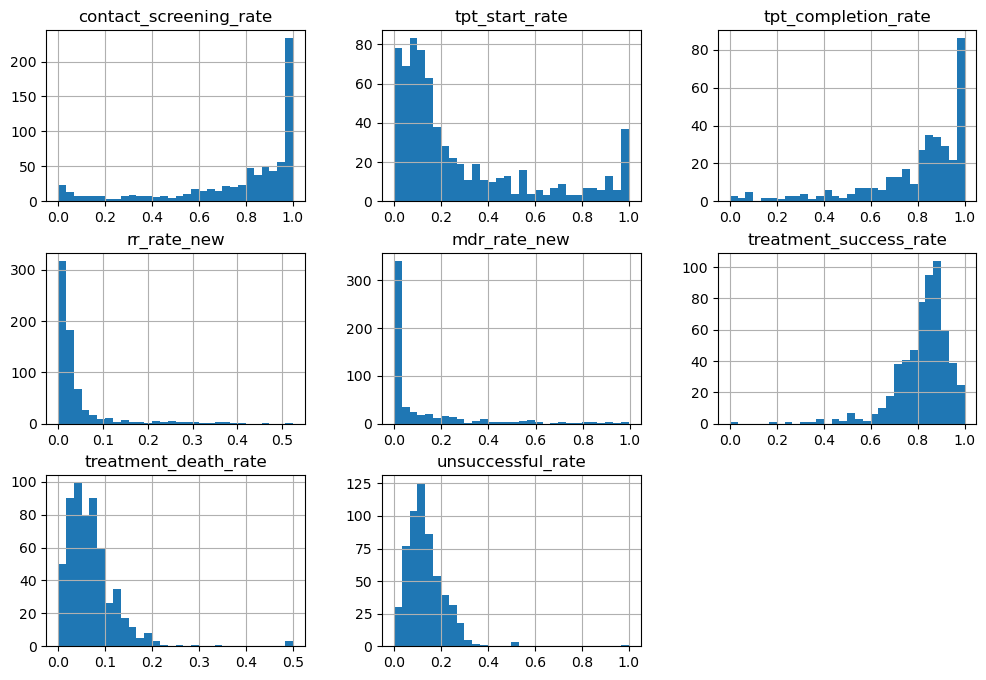

In [47]:
tb_analysis[rate_cols].hist(bins=30, figsize=(12, 8))


<Axes: >

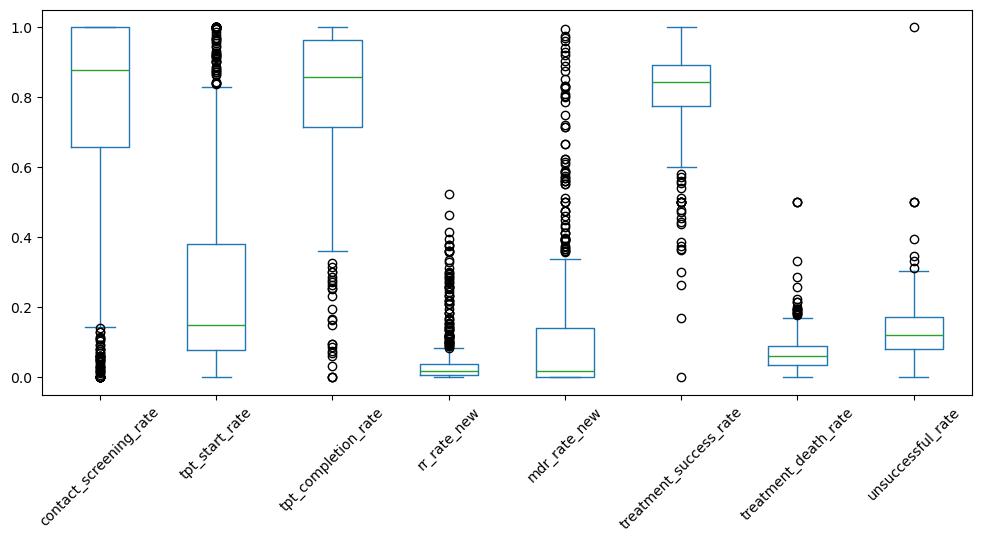

In [48]:
tb_analysis[rate_cols].plot(kind="box", figsize=(12, 5), rot=45)


### Markierung theoretischer Randwerte der Screening- und Präventionsraten

Die Randwertmarkierung erfolgt für die Screening- und Präventionsraten, da diese als Ausgangsvariablen in allen Teilanalysen verwendet werden. Die Randwerte `0` und `1` werden nicht entfernt, da sie innerhalb des zulässigen Wertebereichs liegen. Sie werden jedoch markiert, damit spätere Analysen bei Bedarf mit und ohne diese Randwerte durchgeführt werden können.


In [49]:
edge_rate_cols = [
    "contact_screening_rate",
    "tpt_start_rate",
    "tpt_completion_rate",
]

for col in edge_rate_cols:
    tb_analysis[f"{col}_edge_flag"] = tb_analysis[col].isin([0, 1])

edge_flag_cols = [f"{col}_edge_flag" for col in edge_rate_cols]

tb_analysis[edge_flag_cols].sum().to_frame("n_edge_values")


,n_edge_values
contact_screening_rate_edge_flag,204
tpt_start_rate_edge_flag,51
tpt_completion_rate_edge_flag,68


### Amendment A2: Ergänzung der Outcome-Kohortengröße

Umsetzung der in der zentralen Amendment-Übersicht dokumentierten Ergänzung: `newrel_coh_next_year` wird als Kontextvariable in den Outcome-Analysedatensatz aufgenommen.


### Bildung der Folgejahr-Variablen

Nach der Plausibilitätskorrektur werden die Folgejahr-Spalten erzeugt. Dafür wird ein Self-Merge verwendet. So werden nur echte Kalender-Folgejahre zugeordnet.


In [50]:
next_year_source_cols = [
    "c_newinc",
    "rr_rate_new",
    "mdr_rate_new",
    "c_new_tsr",
    "newrel_coh",
    "treatment_success_rate",
    "treatment_death_rate",
    "unsuccessful_rate",
]

next_year_cols = [f"{col}_next_year" for col in next_year_source_cols]

next_year_values = tb_analysis[["iso3", "year"] + next_year_source_cols].copy()
next_year_values["year"] = next_year_values["year"] - 1
next_year_values = next_year_values.rename(
    columns={col: f"{col}_next_year" for col in next_year_source_cols}
)

tb_analysis = tb_analysis.drop(columns=next_year_cols, errors="ignore")

tb_analysis = tb_analysis.merge(
    next_year_values,
    on=["iso3", "year"],
    how="left",
    validate="one_to_one",
)

tb_analysis[next_year_cols].isna().mean().mul(100).round(2)



c_newinc_next_year                  27.66
rr_rate_new_next_year               32.71
mdr_rate_new_next_year              42.69
c_new_tsr_next_year                 44.95
newrel_coh_next_year                44.68
treatment_success_rate_next_year    44.95
treatment_death_rate_next_year      45.08
unsuccessful_rate_next_year         45.35
dtype: float64

### Berechnung der Fallzahl-Veränderung

Absolute gemeldete TB-Fallzahlen sind ohne Bevölkerungsdaten nur eingeschränkt zwischen Ländern vergleichbar. Eine hohe Fallzahl kann vor allem durch eine große Bevölkerung bedingt sein. Da im vorliegenden WHO-Datensatz keine Bevölkerungszahlen enthalten sind und daher keine Inzidenzen berechnet werden können, wird für die Fallzahlenanalyse die prozentuale Veränderung der gemeldeten Fälle vom aktuellen Jahr zum Folgejahr verwendet. Dadurch wird stärker die Entwicklung innerhalb eines Landes betrachtet. 

Aus der aktuellen Fallzahl und der Fallzahl im Folgejahr wird die prozentuale Veränderung berechnet. Die Werte sind als Prozentwerte zu lesen, z. B. `50` = +50 % und `-25` = -25 %.


In [51]:
case_change_cols = ["c_newinc_percent_change_next_year"]

tb_analysis = tb_analysis.drop(columns=case_change_cols, errors="ignore")

tb_analysis["c_newinc_percent_change_next_year"] = (
    (tb_analysis["c_newinc_next_year"] - tb_analysis["c_newinc"])
    / tb_analysis["c_newinc"]
    * 100
).replace([float("inf"), float("-inf")], float("nan"))

tb_analysis[case_change_cols].isna().mean().mul(100).round(2)


c_newinc_percent_change_next_year    27.79
dtype: float64

### Prüfung der Fallzahl-Veränderungsvariable

Da die prozentuale Veränderung bei kleinen Ausgangsfallzahlen stark ausschlagen kann, wird die neue Zielvariable deskriptiv und grafisch geprüft.


In [52]:
tb_analysis["c_newinc_percent_change_next_year"].describe()


count    543.000000
mean       2.780744
std       31.366239
min      -83.333333
25%       -9.637806
50%        1.099485
75%       10.969227
max      339.583333
Name: c_newinc_percent_change_next_year, dtype: float64

<Axes: >

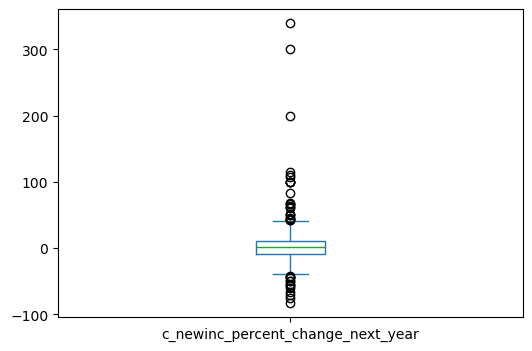

In [53]:
tb_analysis["c_newinc_percent_change_next_year"].plot(kind="box", figsize=(6, 4))


Nach dem Boxplot werden die zehn höchsten prozentualen Fallzahlveränderungen tabellarisch betrachtet. 

In [54]:
tb_analysis.sort_values(
    "c_newinc_percent_change_next_year",
    ascending=False,
)[
    [
        "country",
        "iso3",
        "year",
        "g_whoregion",
        "c_newinc",
        "c_newinc_next_year",
        "c_newinc_percent_change_next_year",
        "contact_screening_rate",
        "tpt_start_rate",
        "tpt_completion_rate",
    ]
].head(10)


,country,iso3,year,g_whoregion,c_newinc,c_newinc_next_year,c_newinc_percent_change_next_year,contact_screening_rate,tpt_start_rate,tpt_completion_rate
233,Micronesia (Federated States of),FSM,2022,WPR,48.0,211.0,339.583333,0.061047,0.043605,NaN
679,Tonga,TON,2022,WPR,2.0,8.0,300.000000,0.437500,0.437500,1.000000
31,American Samoa,ASM,2019,WPR,1.0,3.0,200.000000,0.000000,0.000000,NaN
530,Palau,PLW,2022,WPR,7.0,15.0,114.285714,0.607143,0.250000,1.000000
422,Marshall Islands,MHL,2022,WPR,102.0,215.0,110.784314,0.818898,0.177165,0.666667
77,Bahamas,BHS,2023,AMR,27.0,56.0,107.407407,1.000000,0.800000,1.000000
92,Bermuda,BMU,2022,AMR,1.0,2.0,100.000000,NaN,NaN,NaN
16,Andorra,AND,2021,EUR,2.0,4.0,100.000000,1.000000,0.333333,NaN
34,Antigua and Barbuda,ATG,2020,AMR,2.0,4.0,100.000000,1.000000,0.000000,NaN
441,Montenegro,MNE,2020,EUR,40.0,80.0,100.000000,0.145455,NaN,NaN


**Amendment A4:** Ein Teil der auffälligen Veränderungen entsteht durch sehr kleine Ausgangsfallzahlen. Deshalb werden Länder-Jahr-Beobachtungen mit weniger als 10 gemeldeten TB-Fällen im Ausgangsjahr markiert, aber nicht entfernt. Hohe Fallzahl-Änderungen sind fachlich-epidemiologisch möglich und spannend. Sie werden daher im Datensatz behalten. 

In [55]:
min_cases_for_percent_change = 10
tb_analysis["low_c_newinc_flag"] = (
    tb_analysis["c_newinc"] < min_cases_for_percent_change
)

tb_analysis["low_c_newinc_flag"].value_counts(dropna=False)


low_c_newinc_flag
False    699
True      53
Name: count, dtype: int64

### Amendments A5 und A6: Zeitliche Länder-Jahr-Analyse

Für die deskriptive zeitliche Analyse werden die Richtung der Fallzahlveränderung und die Zugehörigkeit zur konstanten Analysegruppe ergänzt. Die konstante Gruppe umfasst Länder mit Beobachtungen für die Ausgangsjahre 2019-2023 und mindestens 10 Ausgangsfällen in jedem dieser Jahre.


In [57]:
def classify_case_change(value):
    if pd.isna(value):
        return pd.NA
    if value < 0:
        return "Rückgang"
    if value > 0:
        return "Anstieg"
    return "Unverändert"


tb_analysis["case_change_direction"] = tb_analysis[
    "c_newinc_percent_change_next_year"
].apply(classify_case_change)

temporal_candidates = tb_analysis.dropna(
    subset=["contact_screening_rate", "c_newinc_percent_change_next_year"]
).copy()
temporal_analysis_years = sorted(temporal_candidates["year"].unique())
required_years = set(temporal_analysis_years)
country_years = temporal_candidates.groupby("iso3")["year"].agg(set)
complete_countries = country_years[
    country_years.apply(required_years.issubset)
].index
countries_with_low_counts = temporal_candidates.groupby("iso3")[
    "low_c_newinc_flag"
].any()
countries_with_low_counts = countries_with_low_counts[
    countries_with_low_counts
].index
temporal_cohort_countries = complete_countries.difference(
    countries_with_low_counts
)

tb_analysis["temporal_analysis_cohort_flag"] = tb_analysis["iso3"].isin(
    temporal_cohort_countries
)

pd.Series({
    "Ausgangsjahre": f"{min(temporal_analysis_years)}-{max(temporal_analysis_years)}",
    "Länder mit vollständigen Jahren": len(complete_countries),
    "Konstante Analysegruppe": len(temporal_cohort_countries),
})


Ausgangsjahre                      2019-2023
Länder mit vollständigen Jahren           73
Konstante Analysegruppe                   70
dtype: object

In [58]:
id_cols = ["country", "iso3", "year", "g_whoregion"]
exposure_cols = ["contact_screening_rate", "tpt_start_rate", "tpt_completion_rate"]

tb_cases_cols = id_cols + exposure_cols + edge_flag_cols + [
    "c_newinc",
    "c_newinc_next_year",
    "c_newinc_percent_change_next_year",
    "case_change_direction",
    "low_c_newinc_flag",
    "temporal_analysis_cohort_flag",
]
tb_dr_cols = id_cols + exposure_cols + edge_flag_cols + ["rr_rate_new_next_year", "mdr_rate_new_next_year"]
tb_outcome_cols = id_cols + exposure_cols + edge_flag_cols + [
    "c_new_tsr_next_year",
    "newrel_coh_next_year",
    "treatment_success_rate_next_year",
    "treatment_death_rate_next_year",
    "unsuccessful_rate_next_year",
]

tb_cases_analysis = tb_analysis[tb_cases_cols].dropna(
    subset=["contact_screening_rate", "c_newinc_percent_change_next_year"]
).copy()

tb_dr_analysis = tb_analysis[tb_dr_cols].dropna(
    subset=["contact_screening_rate", "rr_rate_new_next_year", "mdr_rate_new_next_year"]
).copy()

tb_outcome_analysis = tb_analysis[tb_outcome_cols].dropna(
    subset=["contact_screening_rate", "c_new_tsr_next_year"]
).copy()


### Größenvergleich der Analyse-Datensätze

In [59]:
subtable_shapes = pd.DataFrame(
    {
        "rows": [tb_cases_analysis.shape[0], tb_dr_analysis.shape[0], tb_outcome_analysis.shape[0]],
        "columns": [tb_cases_analysis.shape[1], tb_dr_analysis.shape[1], tb_outcome_analysis.shape[1]],
    },
    index=["tb_cases_analysis", "tb_dr_analysis", "tb_outcome_analysis"],
)

subtable_shapes

,rows,columns
tb_cases_analysis,540,16
tb_dr_analysis,423,12
tb_outcome_analysis,413,15


### Amendment A7: Regionale Datenabdeckung

Die WHO-Regionen umfassen unterschiedlich viele Länder und Gebiete. Deshalb werden nicht nur Länder-Jahr-Anteile, sondern die Zahl der vertretenen Länder und ihre Abdeckung relativ zum WHO-Contact-Ausgangsdatensatz für 2019–2023 betrachtet.

- AFR = Africa
- AMR = Americas
- EMR = Eastern Mediterranean
- EUR = Europe
- SEA = South-East Asia
- WPR = Western Pacific


In [60]:
source_region_countries = (
    contact[contact["year"].isin(temporal_analysis_years)]
    .groupby("g_whoregion")["iso3"]
    .nunique()
)

regional_country_counts = pd.DataFrame({
    "WHO-Ausgangsdaten": source_region_countries,
    "Fallzahl-Analyse": tb_cases_analysis.groupby("g_whoregion")["iso3"].nunique(),
    "Resistenz-Analyse": tb_dr_analysis.groupby("g_whoregion")["iso3"].nunique(),
    "Outcome-Analyse": tb_outcome_analysis.groupby("g_whoregion")["iso3"].nunique(),
    "Konstante Zeitgruppe": (
        tb_cases_analysis[tb_cases_analysis["temporal_analysis_cohort_flag"]]
        .groupby("g_whoregion")["iso3"]
        .nunique()
    ),
}).fillna(0).astype(int)

regional_coverage_percent = regional_country_counts.iloc[:, 1:].div(
    regional_country_counts["WHO-Ausgangsdaten"], axis=0
).mul(100).round(1)

print("Anzahl Länder und Gebiete:")
display(regional_country_counts)
print("Abdeckung relativ zu den WHO-Ausgangsdaten (%):")
display(regional_coverage_percent)


Anzahl Länder und Gebiete:


,WHO-Ausgangsdaten,Fallzahl-Analyse,Resistenz-Analyse,Outcome-Analyse,Konstante Zeitgruppe
g_whoregion,,,,,
AFR,47,37,32,33,11
AMR,45,32,25,28,16
EMR,22,18,18,18,11
EUR,54,24,22,22,12
SEA,10,9,6,8,6
WPR,37,25,18,24,14


Abdeckung relativ zu den WHO-Ausgangsdaten (%):


,Fallzahl-Analyse,Resistenz-Analyse,Outcome-Analyse,Konstante Zeitgruppe
g_whoregion,,,,
AFR,78.7,68.1,70.2,23.4
AMR,71.1,55.6,62.2,35.6
EMR,81.8,81.8,81.8,50.0
EUR,44.4,40.7,40.7,22.2
SEA,90.0,60.0,80.0,60.0
WPR,67.6,48.6,64.9,37.8


Die absoluten Länderzahlen unterscheiden sich bereits deshalb, weil die WHO-Regionen unterschiedlich groß sind. SEA umfasst im Ausgangsdatensatz nur 10 Länder, von denen 9 in der Fallzahlanalyse und 6 in der konstanten Zeitgruppe enthalten sind. Die Abdeckung ist damit relativ hoch, regionale Kennzahlen beruhen dort aber auf wenigen Ländern. EUR umfasst dagegen 54 Länder und Gebiete, von denen nur ca 45 % in die Fallzahlanalyse eingehen, wodurch die Aussagekraft für europäische Länder reduziert ist. Die Aussagekraft der Analyse des zeitlichen Einflusses wird in allen WHO Regionen reduziert sein, da entweder nur weniger als die Hälfte der Länder abgedeckt sind, oder die Regionen nur aus wenigen Ländern bestehen. 

### Kurzer Blick in die finalen Analyse-Datensätze

In [69]:
tb_cases_analysis.head()

,country,iso3,year,g_whoregion,contact_screening_rate,tpt_start_rate,tpt_completion_rate,contact_screening_rate_edge_flag,tpt_start_rate_edge_flag,tpt_completion_rate_edge_flag,c_newinc,c_newinc_next_year,c_newinc_percent_change_next_year,case_change_direction,low_c_newinc_flag,temporal_analysis_cohort_flag
2,Afghanistan,AFG,2019,EMR,0.900174,0.754529,0.870613,False,False,False,52438.0,45818.0,-12.624433,Rückgang,False,True
3,Afghanistan,AFG,2020,EMR,0.093804,1.000000,0.872043,False,True,False,45818.0,50324.0,9.834563,Anstieg,False,True
4,Afghanistan,AFG,2021,EMR,0.868433,0.722507,0.950000,False,False,False,50324.0,51749.0,2.831651,Anstieg,False,True
5,Afghanistan,AFG,2022,EMR,0.113818,0.087911,0.920000,False,False,False,51749.0,49533.0,-4.282208,Rückgang,False,True
6,Afghanistan,AFG,2023,EMR,0.217650,0.139266,0.894918,False,False,False,49533.0,51319.0,3.605677,Anstieg,False,True


In [70]:
tb_dr_analysis.head()

,country,iso3,year,g_whoregion,contact_screening_rate,tpt_start_rate,tpt_completion_rate,contact_screening_rate_edge_flag,tpt_start_rate_edge_flag,tpt_completion_rate_edge_flag,rr_rate_new_next_year,mdr_rate_new_next_year
2,Afghanistan,AFG,2019,EMR,0.900174,0.754529,0.870613,False,False,False,0.027304,0.186501
4,Afghanistan,AFG,2021,EMR,0.868433,0.722507,0.950000,False,False,False,0.052821,0.134409
5,Afghanistan,AFG,2022,EMR,0.113818,0.087911,0.920000,False,False,False,0.021208,0.013836
6,Afghanistan,AFG,2023,EMR,0.217650,0.139266,0.894918,False,False,False,0.015022,0.716312
9,Albania,ALB,2020,EUR,0.571429,0.809524,0.647059,False,False,False,0.032468,0.010101


In [71]:
tb_outcome_analysis.head()

,country,iso3,year,g_whoregion,contact_screening_rate,tpt_start_rate,tpt_completion_rate,contact_screening_rate_edge_flag,tpt_start_rate_edge_flag,tpt_completion_rate_edge_flag,c_new_tsr_next_year,newrel_coh_next_year,treatment_success_rate_next_year,treatment_death_rate_next_year,unsuccessful_rate_next_year
2,Afghanistan,AFG,2019,EMR,0.900174,0.754529,0.870613,False,False,False,95.0,45818.0,0.947684,0.014077,0.032214
3,Afghanistan,AFG,2020,EMR,0.093804,1.000000,0.872043,False,True,False,93.0,50324.0,0.925642,0.011585,0.029469
4,Afghanistan,AFG,2021,EMR,0.868433,0.722507,0.950000,False,False,False,95.0,50976.0,0.946485,0.016949,0.033918
5,Afghanistan,AFG,2022,EMR,0.113818,0.087911,0.920000,False,False,False,94.0,49533.0,0.942927,0.020168,0.036642
8,Albania,ALB,2019,EUR,0.442623,0.885246,0.425926,False,False,False,89.0,240.0,0.887500,0.058333,0.108333


## 6. Finale Validierung und Export

Zum Abschluss werden die bereinigten Datensätze noch einmal auf Duplikate, fehlende Werte und die finalen Dimensionen geprüft. Danach werden der zentrale bereinigte Datensatz sowie die drei Analyse-Subdatensätze exportiert.


### Finaler Duplikat-Check


In [72]:
final_duplicate_check = pd.Series(
    {
        "tb_analysis": tb_analysis.duplicated(subset=["iso3", "year"]).sum(),
        "tb_cases_analysis": tb_cases_analysis.duplicated(subset=["iso3", "year"]).sum(),
        "tb_dr_analysis": tb_dr_analysis.duplicated(subset=["iso3", "year"]).sum(),
        "tb_outcome_analysis": tb_outcome_analysis.duplicated(subset=["iso3", "year"]).sum(),
    },
    name="duplicate_iso3_year",
)

final_duplicate_check


tb_analysis            0
tb_cases_analysis      0
tb_dr_analysis         0
tb_outcome_analysis    0
Name: duplicate_iso3_year, dtype: int64

### Finale Missing-Value-Übersicht

Die fehlenden Werte werden für die drei Analyse-Subdatensätze separat betrachtet, da sie unterschiedliche Zielvariablen enthalten und daher unterschiedlich stark von fehlenden Folgejahrdaten betroffen sind.


In [73]:
final_missing_values = pd.concat(
    {
        "tb_cases_analysis": tb_cases_analysis.isna().mean().mul(100).round(2),
        "tb_dr_analysis": tb_dr_analysis.isna().mean().mul(100).round(2),
        "tb_outcome_analysis": tb_outcome_analysis.isna().mean().mul(100).round(2),
    },
    axis=1,
)

final_missing_values


,tb_cases_analysis,tb_dr_analysis,tb_outcome_analysis
country,0.00,0.00,0.00
iso3,0.00,0.00,0.00
year,0.00,0.00,0.00
g_whoregion,0.00,0.00,0.00
contact_screening_rate,0.00,0.00,0.00
tpt_start_rate,7.59,6.38,7.51
tpt_completion_rate,36.85,34.52,38.50
contact_screening_rate_edge_flag,0.00,0.00,0.00
tpt_start_rate_edge_flag,0.00,0.00,0.00
tpt_completion_rate_edge_flag,0.00,0.00,0.00


### Finale Größenübersicht


In [74]:
final_shapes = pd.DataFrame(
    {
        "rows": [
            tb_analysis.shape[0],
            tb_cases_analysis.shape[0],
            tb_dr_analysis.shape[0],
            tb_outcome_analysis.shape[0],
        ],
        "columns": [
            tb_analysis.shape[1],
            tb_cases_analysis.shape[1],
            tb_dr_analysis.shape[1],
            tb_outcome_analysis.shape[1],
        ],
    },
    index=["tb_analysis", "tb_cases_analysis", "tb_dr_analysis", "tb_outcome_analysis"],
)

final_shapes


,rows,columns
tb_analysis,752,60
tb_cases_analysis,540,16
tb_dr_analysis,423,12
tb_outcome_analysis,413,15


### Export der bereinigten Datensätze

`tb_analysis` ist der zentrale bereinigte Datensatz. Die drei zusätzlichen CSV-Dateien sind daraus abgeleitete Analyse-Subdatensätze für die jeweiligen Teilfragen.


In [75]:
from pathlib import Path

output_dir = Path("cleaned_data")
output_dir.mkdir(exist_ok=True)

tb_analysis.to_csv(output_dir / "tb_analysis_cleaned.csv", index=False)
tb_cases_analysis.to_csv(output_dir / "tb_cases_analysis_cleaned.csv", index=False)
tb_dr_analysis.to_csv(output_dir / "tb_dr_analysis_cleaned.csv", index=False)
tb_outcome_analysis.to_csv(output_dir / "tb_outcome_analysis_cleaned.csv", index=False)

exported_files = sorted(path.name for path in output_dir.glob("*.csv"))
exported_files


['tb_analysis_cleaned.csv',
 'tb_cases_analysis_cleaned.csv',
 'tb_dr_analysis_cleaned.csv',
 'tb_outcome_analysis_cleaned.csv']

### Zusammenfassung der Datenbereinigung

- Die vier WHO-Rohdatensätze wurden importiert und auf forschungsrelevante Spalten reduziert.
- Die Datensätze wurden über `iso3` und `year` zusammengeführt; diese Schlüssel wurden zuvor auf Duplikate geprüft.
- Aus den Rohvariablen wurden Screening-, Präventions-, Resistenz- und Therapieergebnisraten sowie die prozentuale Veränderung der gemeldeten TB-Fälle berechnet.
- Unplausible Raten außerhalb des Wertebereichs `0` bis `1` wurden auf `NaN` gesetzt.
- Folgejahrvariablen wurden per Self-Merge gebildet, damit nur echte Kalender-Folgejahre zugeordnet werden.
- Randwerte von `0` und `1` wurden für die Screening- und Präventionsraten im Ausgangsjahr nicht entfernt, sondern mit Flag-Spalten markiert.
- Resistenzraten mit dem Wert `1.0` wurden als epidemiologisch nicht belastbare Randwerte auf `NaN` gesetzt.
- Die Outcome-Kohortengröße im Folgejahr (`newrel_coh_next_year`) wurde als Kontextvariable ergänzt.
- `newinc_con_tb` wurde als explorative Zusatzvariable beibehalten; `used_2021_defs_flg` wurde aus dem Analyseexport entfernt.
- Rechnerisch plausible extreme Fallzahlveränderungen wurden nicht automatisch per IQR-Regel entfernt.
- `case_change_direction` und `temporal_analysis_cohort_flag` wurden für die zeitliche Länder-Jahr-Analyse ergänzt.
- Die regionale Abdeckung wurde anhand eindeutiger Länder relativ zum WHO-Ausgangsdatensatz geprüft.
- Fehlende Werte wurden nicht global imputiert. Stattdessen wurden für die drei Teilfragen separate Analyse-Subdatensätze gebildet.
- Der zentrale bereinigte Datensatz ist `tb_analysis_cleaned.csv`; die drei weiteren Dateien sind analysebezogene Ausschnitte.


### Export der Cleaning-Dokumentation

Die Zusammenfassung bleibt im Notebook dokumentiert. Zusätzlich wird eine kurze Textdatei geschrieben, damit wie im Kursbeispiel eine separate Cleaning-Dokumentation vorliegt.


In [76]:
cleaning_doc = f"""DOKUMENTATION DATA CLEANING - WHO TB PROJEKT

Rohdaten:
- Contact: {contact.shape[0]} Zeilen, {contact.shape[1]} Spalten
- Notifications: {notifications.shape[0]} Zeilen, {notifications.shape[1]} Spalten
- Drug resistance: {drug_resistance.shape[0]} Zeilen, {drug_resistance.shape[1]} Spalten
- Outcomes: {outcomes.shape[0]} Zeilen, {outcomes.shape[1]} Spalten

Bereinigte Datensätze:
- tb_analysis_cleaned.csv: {tb_analysis.shape[0]} Zeilen, {tb_analysis.shape[1]} Spalten
- tb_cases_analysis_cleaned.csv: {tb_cases_analysis.shape[0]} Zeilen, {tb_cases_analysis.shape[1]} Spalten
- tb_dr_analysis_cleaned.csv: {tb_dr_analysis.shape[0]} Zeilen, {tb_dr_analysis.shape[1]} Spalten
- tb_outcome_analysis_cleaned.csv: {tb_outcome_analysis.shape[0]} Zeilen, {tb_outcome_analysis.shape[1]} Spalten

Wichtige Cleaning-Schritte:
- Auswahl forschungsrelevanter Spalten
- Merge über iso3 und year
- Berechnung von Raten, Folgejahrvariablen und prozentualer Veränderung der gemeldeten TB-Fälle
- Unplausible Raten < 0 oder > 1 auf NaN gesetzt
- Randwerte 0 und 1 bei Screening- und Präventionsraten markiert, aber nicht entfernt
- Resistenzraten mit Wert 1.0 auf NaN gesetzt
- Outcome-Kohortengröße im Folgejahr ergänzt
- Variablen mit sehr hoher Datenlücke und ohne Verwendung aus dem Analyseexport entfernt
- Rechnerisch plausible extreme Fallzahlveränderungen beibehalten
- Richtung der Fallzahlveränderung und konstante zeitliche Analysegruppe ergänzt
- Regionale Länderabdeckung relativ zum WHO-Ausgangsdatensatz geprüft
- Keine globale Imputation fehlender Werte
- Finale Duplikatprüfung über iso3 und year
"""

(output_dir / "cleaning_doc.txt").write_text(cleaning_doc, encoding="utf-8")
print(cleaning_doc)


DOKUMENTATION DATA CLEANING - WHO TB PROJEKT

Rohdaten:
- Contact: 2150 Zeilen, 36 Spalten
- Notifications: 9567 Zeilen, 216 Spalten
- Drug resistance: 1720 Zeilen, 57 Spalten
- Outcomes: 6399 Zeilen, 73 Spalten

Bereinigte Datensätze:
- tb_analysis_cleaned.csv: 752 Zeilen, 60 Spalten
- tb_cases_analysis_cleaned.csv: 540 Zeilen, 16 Spalten
- tb_dr_analysis_cleaned.csv: 423 Zeilen, 12 Spalten
- tb_outcome_analysis_cleaned.csv: 413 Zeilen, 15 Spalten

Wichtige Cleaning-Schritte:
- Auswahl forschungsrelevanter Spalten
- Merge über iso3 und year
- Berechnung von Raten, Folgejahrvariablen und prozentualer Veränderung der gemeldeten TB-Fälle
- Unplausible Raten < 0 oder > 1 auf NaN gesetzt
- Randwerte 0 und 1 bei Screening- und Präventionsraten markiert, aber nicht entfernt
- Resistenzraten mit Wert 1.0 auf NaN gesetzt
- Outcome-Kohortengröße im Folgejahr ergänzt
- Variablen mit sehr hoher Datenlücke und ohne Verwendung aus dem Analyseexport entfernt
- Rechnerisch plausible extreme Fallzahlv

## 7. Reflexion 

### Größte Herausforderungen: 
- Art der Datensätze: Die Datensätze stellten für mich eine Herausforderung dar, da die einzelnen Zeilen immer ein Land pro Jahr darstellten. In Summe gab es sehr viele Zeilen und Daten, die jedoch kleinen Clustern (Länderdaten) entsprachen. Die folgenden Punkte stellten dabei besondere Herausfoderungen dar.
  - Fehlende Werte: Initial war ich davon ausgegangen, dass ich bei der Menge der Daten leicht eine Interpolation bei fehlenden Werten vornehmen können würde. Bei genauerer Betrachtung stellte ich jedoch fest, dass ich Daten nicht über den gesamten Datensatz mitteln kann, sondern immer nur in ihren Clustern betrachten darf. Dadurch reduzierte sich die Menge der Daten, die ich für eine Interpolation heranziehen konnte drastisch. Daher habe ich auf eine globale Imputation verzichtet und fehlende Werte abhängig von der jeweiligen Teilfrage behandelt. Dadurch entstand keine relevante Ungleichverteilung von Daten über die WHO-Regionen.
  - Outlier Detection: Auch bei diesem Schritt stieß ich auf zwei Probleme. Das erste war die Outlier-Detection von Absolutwerten. Diese habe ich schnell als wenig zielführend bewertet, da Werte wie Fallzahlen von Landesgröße/ und -bevölkerung, TB-Burden und TB-Meldestrategie abhängen. Eine Analyse über alle Daten hinweg wird der Realität nicht gerecht und entfernt plausible Werte, eine Analyse in den Landes-Clustern ist bei geringer Datenzahl ebenfalls nicht hilfreich. Daher wollte ich die Outlier Detection über die berechneten Raten durchführen. Das stellte mich jedoch vor die zweite Herausforderung, dass der Wertebereich nur zwischen 0 und 1 liegt und dabei Ausreißer in meinen Daten weniger stark ausfallen, da sie sich nicht so weit vom Mittelwert entfernen können. Es entstehen theoretische Randwerte 0 und 1: Es ist vorstellbar, dass 0% oder 100% der Kontaktpersonen gescreent werden, aber es ist auffällig. Die theoretischen Randwerte der Ausgangsvariablen habe ich daher markiert um im Verlauf die Analyse mit und ohne Randwerte durchführen zu können. 

### Schwierigste Entscheidungen:
- Anpassung der Zielvariable: Absolute Fallzahlen müssen im Kontext der Einwohnerzahl gesehen werden, da eine Fallzahl von 100 bei einer Einwohnerzahl von 100 eine andere Bedeutung hat, als bei einer Einwohnerzahl von 10.000. Da mir im Datensatz keine Information zur Einwohnerzahl vorliegt, habe ich mich entschieden Prozentwerte des Anstiegs/ Abfalls der Fallzahlen zu berechnen um eine bessere Vergleichbarkeit zu gewährleisten. Die Entscheidung fiel mir nicht leicht, da ich das Gefühl hatte in meiner initialen Projektbeschreibung einen Fehler gemacht zu haben. 

- Erneute Auftrennung des Analysedatensatzes in drei Sub-Datensätze: Da die Daten zur Beantworutng meiner drei Teilfragen teils stark unterschiedliche fehlende NA-Werte haben und ich verhindern möchte, dass Daten-Zeilen entfernt werden, weil für Frage A Daten fehlen, während sie für Frage B vollständig vorhanden wären, habe ich erneut die Daten aufgetrennt.  

### Erkentnisse: 
Ich habe gelernt, dass initiale Annahmen bei der Arbeit an einem Datensatz verworfen werden können wenn neue Erkenntnisse / Einsichten zu Tage treten. Insbesondere habe ich dabei genlernt, dass es kein Versagen ist, sondern ein Resultat der fachlichen Auseinadersetzung ist. Der größere Fehler würde entstehen, neue Erkenntnisse nicht zu berückstichtigen. 

### Zuversicht (1-10):
Ich bin sehr zuversichtlich (8-9), dass mein Datensatz für meine Forschungsfrage gut vorbereitet ist. Eine gewisse Restunsicherheit bleibt, da die WHO-Daten viele fehlende Werte enthalten und die Aussagekraft je nach Teilfrage wahrscheinlich unterschiedlich stark ist. Ich bin auch gespannt, wie die markierten Werte die Analyse ggf. beeinflussen.  